Incorporating correction for the selection effects with numpyro's model.

In [208]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import emcee

import jax
import numpyro
import jax.numpy as jnp
import numpyro.distributions as dist

from chainconsumer import ChainConsumer, Chain

import getdist
from getdist import plots, MCSamples

from jax.scipy.special import erf as jax_erf, log_ndtr
from jax.scipy.stats import norm
from jax.scipy.integrate import trapezoid


def getdist_plot(results_chain, param_names, true_params, pred_params):
    # Create getdist object from chain
    getdist_mcsample = getdist.MCSamples(samples=results_chain.T, names=param_names)

    # Triangle plot
    g = getdist.plots.get_subplot_plotter()
    g.settings.legend_fontsize = 25
    g.settings.axes_fontsize = 15
    g.settings.axes_labelsize = 20
    g.triangle_plot(roots=getdist_mcsample, filled=True)

    ndim = results_chain.shape[0]

    for i in range(ndim):
        for j in range(ndim):
            if j <= i:
                ax = g.subplots[i, j]

                # Diagonal
                if i == j:
                    ax.axvline(true_params[i], color='r', ls='--')
                    # ax.axvline(pred_params[i], color='g', ls='--')
                else:
                    # Off-diagonal
                    ax.axvline(true_params[j], color='r', ls='--')
                    ax.axhline(true_params[i], color='r', ls='--')

                    # ax.axvline(pred_params[j], color='g', ls='--')
                    # ax.axhline(pred_params[i], color='g', ls='--')

                ax.set_xlabel(ax.get_xlabel(), usetex=True, fontsize=25, family='sans-serif')
                ax.set_ylabel(ax.get_ylabel(), usetex=True, fontsize=25, family='sans-serif')
                ax.tick_params(axis='both', which='major', labelsize=15)


# Truncated 1D Gaussian with no errors

True parameters:  [5.0, 1.0, 3.5]
Predicted parameters:  [Array(5.1396623, dtype=float32), Array(0.88122535, dtype=float32), Array(3.5001721, dtype=float32)]


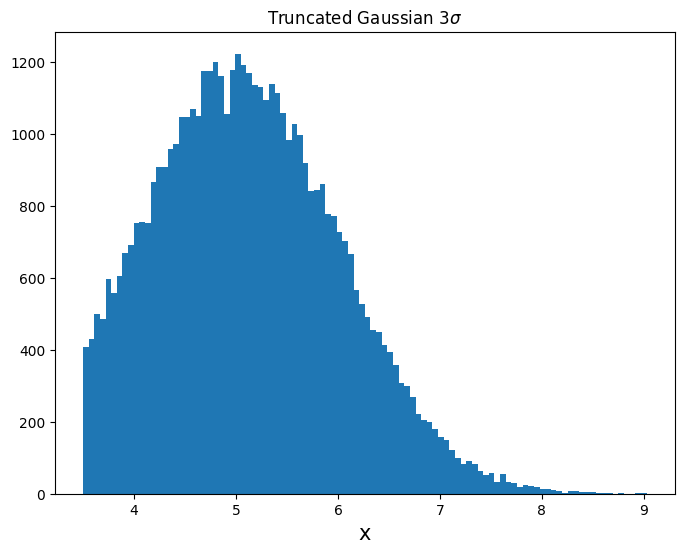

In [125]:
np.random.seed(42)

# Generate data
sigma_cut = 1.5
N_data = 50000
mean_x = 5.0
sigma_x = 1.0
x_min = mean_x - sigma_cut * sigma_x
true_params = [mean_x, sigma_x, x_min]

x_data = dist.TruncatedNormal(loc=mean_x, scale=sigma_x, low=x_min).sample(jax.random.PRNGKey(0), sample_shape=(N_data,))

# Predicted analytical values
mu_x_pred = np.mean(x_data)
sigma_x = np.std(x_data)
low_x_pred = np.min(x_data)
pred_params = [mu_x_pred, sigma_x, low_x_pred]

print("True parameters: ", true_params)
print("Predicted parameters: ", pred_params)

plt.figure(figsize=(8, 6))
plt.title(r'Truncated Gaussian $3\sigma$')
plt.hist(x_data, bins=100)
plt.xlabel('x', fontsize=15)
plt.show()

## NumPyro's truncated normal

In [3]:
def model_truncated_1D_normal(Y):

    # Prior
    mu = numpyro.sample('mu', dist.Uniform(-10., 10.))
    log_sigma = numpyro.sample('log_sigma', dist.Uniform(-1., 1.))

    sigma = numpyro.deterministic('sigma', jnp.exp(log_sigma))

    with numpyro.plate('data', len(Y)):
        numpyro.sample('obs', dist.TruncatedNormal(loc=mu, scale=sigma, low=x_min), obs=Y)

sampler = numpyro.infer.MCMC(
    numpyro.infer.NUTS(model_truncated_1D_normal),
    num_chains=1,
    num_warmup=1000,
    num_samples=5000
)

sampler.run(jax.random.PRNGKey(0), x_data)

sample: 100%|██████████| 6000/6000 [00:03<00:00, 1653.37it/s, 7 steps of size 3.77e-01. acc. prob=0.93] 


Removed no burn in


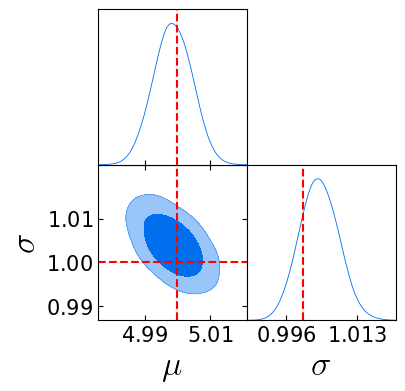

In [4]:
results_chain = sampler.get_samples()

res = np.array([results_chain['mu'], results_chain['sigma']])#, results_chain['lower']])

param_names = [r'$\mu$', r'$\sigma$']#, r'$x_\mathrm{min}$']
getdist_plot(res, param_names, true_params, pred_params)

## Full normal + $f_n$ correction

Use `log_ndtr` from scipy. Supposedly it is more stable.

In [133]:
@jax.jit
def log_f_n_1D_gauss(x_cut: float, mu: float, sigma: float):
    """Calculate the normalisation of the 1D Gaussian likelihood, given the limit on x and the mean and std of the Gaussian"""

    f_n = 0.5 * (1 - jax_erf((x_cut - mu) / (sigma * jnp.sqrt(2))))

    return jnp.log(f_n)


def model_1D_gauss(x, x_cut):

    mu = numpyro.sample('mu', dist.Uniform(-20., 20.))
    sigma = numpyro.sample('sigma', dist.HalfNormal(10))

    # Calculate the correction function (and add to the likelihood)
    z_val = (x_cut - mu) / sigma
    log_fn = log_ndtr(-z_val)

    with numpyro.plate('data', len(x)):
        loglike_full = dist.Normal(mu, sigma).log_prob(x)
        numpyro.factor('loglike', loglike_full - log_fn)


sampler = numpyro.infer.MCMC(
    numpyro.infer.NUTS(model_1D_gauss),
    num_chains=1,
    num_warmup=1000,
    num_samples=3000
)

sampler.run(jax.random.PRNGKey(0), x_data, x_min)

sample: 100%|██████████| 4000/4000 [00:03<00:00, 1216.67it/s, 7 steps of size 1.87e-01. acc. prob=0.91] 


Removed no burn in


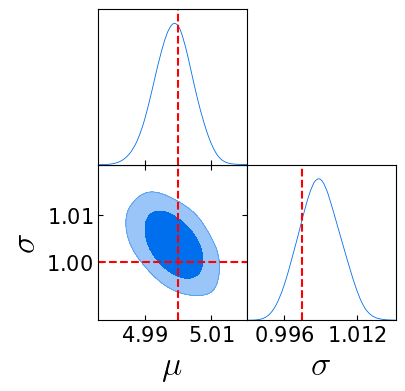

In [134]:
results_chain = sampler.get_samples()

res = np.array([results_chain['mu'], results_chain['sigma']])#, results_chain['lower']])

param_names = [r'$\mu$', r'$\sigma$']#, r'$x_\mathrm{min}$']
getdist_plot(res, param_names, true_params, pred_params)

# Truncated 1D Gaussian with errors

Add the errors first and then truncate (mimicking real scenario).

True parameters:  [5.0, 2.0, 1.5]
Predicted parameters:  [Array(5.1396623, dtype=float32), Array(0.88122535, dtype=float32), Array(3.5001721, dtype=float32)]


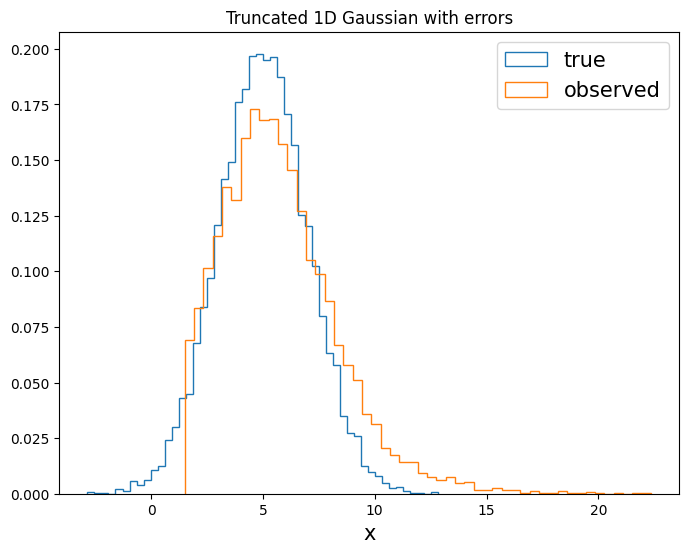

In [142]:
np.random.seed(42)

# Generate data
sigma_cut = 1.5
N_data = 10000
mean_x = 5.0
sigma_x = 2.0
x_min = 1.5
err_x_scale = 2.5
true_params = [mean_x, sigma_x, x_min]

# Convolve true distribution with error distribution
x_true = np.random.normal(loc=mean_x, scale=sigma_x, size=N_data)
err_x = dist.HalfNormal(err_x_scale).sample(jax.random.PRNGKey(0), sample_shape=(N_data, ))
x_true_with_err = x_true + np.random.normal(size=N_data) * err_x

# Truncate the data
mask = x_true_with_err >= x_min
x_obs = x_true_with_err[mask]
err_x = err_x[mask]

print("True parameters: ", true_params)
print("Predicted parameters: ", pred_params)

plt.figure(figsize=(8, 6))
plt.title(r'Truncated 1D Gaussian with errors')
plt.hist(x_true, bins=50, label='true', density=True, histtype='step')
plt.hist(x_obs, bins=50, label='observed', density=True, histtype='step')
plt.xlabel('x', fontsize=15)
plt.legend(fontsize=15)
plt.show()

In [143]:
def model_1D_gauss_with_err(x, err_x, x_cut):

    mu = numpyro.sample('mu', dist.Uniform(-20., 20.))
    sigma = numpyro.sample('sigma', dist.HalfNormal(10))

    # Calculate the correction function (and add to the likelihood)
    z_val = (x_cut - mu) / jnp.sqrt(sigma**2 + err_x**2)
    log_fn = log_ndtr(-z_val)

    with numpyro.plate('data', len(x)):
        loglike_full = dist.Normal(mu, jnp.sqrt(sigma**2 + err_x**2)).log_prob(x)
        numpyro.factor('loglike', loglike_full - log_fn)

sampler = numpyro.infer.MCMC(
    numpyro.infer.NUTS(model_1D_gauss_with_err),
    num_chains=1,
    num_warmup=1000,
    num_samples=3000
)

sampler.run(jax.random.PRNGKey(0), x_obs, err_x, x_min)

sample: 100%|██████████| 4000/4000 [00:03<00:00, 1071.77it/s, 7 steps of size 6.41e-01. acc. prob=0.91] 


Removed no burn in


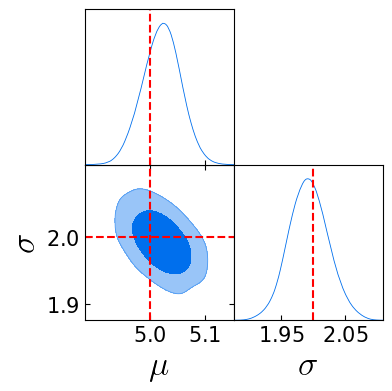

In [144]:
results_chain = sampler.get_samples()

res = np.array([results_chain['mu'], results_chain['sigma']])#, results_chain['lower']])

param_names = [r'$\mu$', r'$\sigma$']#, r'$x_\mathrm{min}$']
getdist_plot(res, param_names, true_params, pred_params)

# Truncated 3D Gaussian + no errors + hard cut on 1 dimension

Text(0, 0.5, 'z')

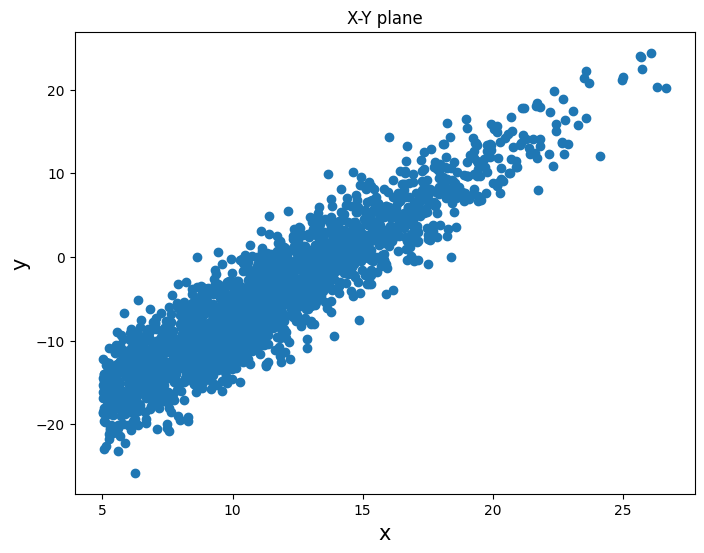

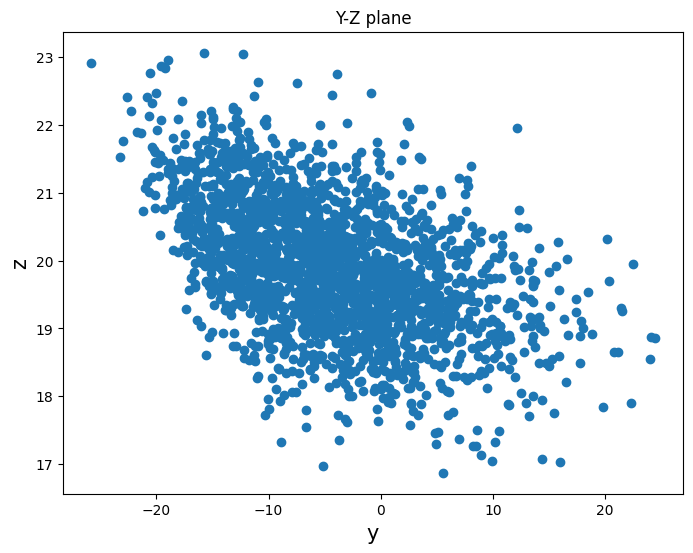

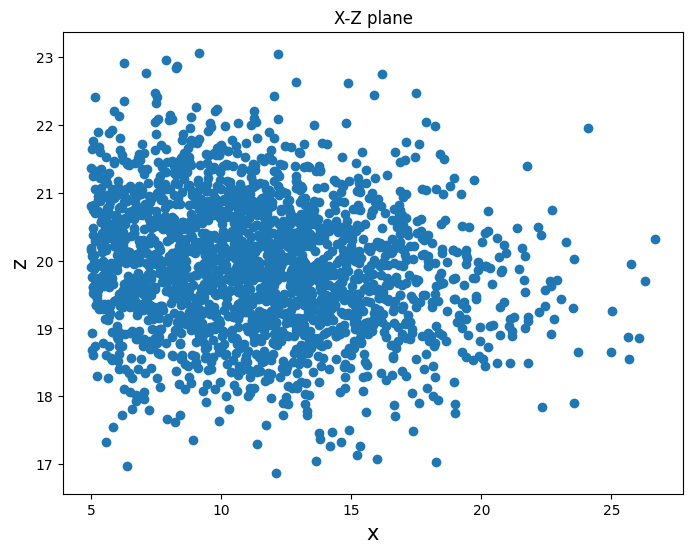

In [145]:
np.random.seed(42)

# Generate data
mean_x = 10.0
mean_y = -7.5
mean_z = 20.0
sigma_x = 5.0
sigma_y = 10.0
sigma_z = 1.0
rho_xy = 0.95
rho_yz = -0.5
rho_xz = -0.25
true_params = [mean_x, mean_y, mean_z, sigma_x, sigma_y, sigma_z, rho_xy, rho_yz, rho_xz]

mean_vec = np.array([mean_x, mean_y, mean_z])
cov_xy = rho_xy * sigma_x * sigma_y
cov_yz = rho_yz * sigma_y * sigma_z
cov_xz = rho_xz * sigma_x * sigma_z
cov_matrix = np.array([
    [sigma_x**2, cov_xy, cov_xz],
    [cov_xy, sigma_y**2, cov_yz],
    [cov_xz, cov_yz, sigma_z**2],
])

data_true = np.random.multivariate_normal(mean=mean_vec, cov=cov_matrix, size=2500)
x_true, y_true, z_true = data_true.T

# Truncate the data
x_min = 5.0
mask = x_true >= x_min
x_obs = x_true[mask]
y_obs = y_true[mask]
z_obs = z_true[mask]
data_obs = np.vstack([x_obs, y_obs, z_obs]).T

plt.figure(figsize=(8, 6))
plt.title('X-Y plane')
plt.scatter(x_obs, y_obs)
plt.xlabel('x', fontsize=15)
plt.ylabel('y', fontsize=15)

plt.figure(figsize=(8, 6))
plt.title('Y-Z plane')
plt.scatter(y_obs, z_obs)
plt.xlabel('y', fontsize=15)
plt.ylabel('z', fontsize=15)

plt.figure(figsize=(8, 6))
plt.title('X-Z plane')
plt.scatter(x_obs, z_obs)
plt.xlabel('x', fontsize=15)
plt.ylabel('z', fontsize=15)

In [147]:
def numpyro_model_truncated_3D(data, x_cut):

    # Dimension and number of data
    d = data.shape[1]
    N = data.shape[0]

    # Vector of variances for each observation
    theta = numpyro.sample('theta', dist.HalfCauchy(jnp.ones(d)))

    # Correlation matrix sampled from LKJ distribution
    concentration = jnp.ones(1) # Uniform prior
    corr_mat = numpyro.sample('corr_mat', dist.LKJ(d, concentration))

    # Construct covariance matrix back
    sigma = jnp.sqrt(theta)
    cov_mat = jnp.matmul(jnp.matmul(jnp.diag(sigma), corr_mat), jnp.diag(sigma))

    # Vector of expectation values (means)
    mu_x = numpyro.sample('mu_x', dist.Uniform(-50., 50.))
    mu_y = numpyro.sample('mu_y', dist.Uniform(-50., 50.))
    mu_z = numpyro.sample('mu_z', dist.Uniform(-50., 50.))
    mu = jnp.array([mu_x, mu_y, mu_z])

    # Calculate the f_n correction
    sigma_x = sigma[0]
    z_val = (x_cut - mu_x) / sigma_x
    log_fn = log_ndtr(-z_val)

    # --- full log likelihood ---
    with numpyro.plate("data", N):
        loglike_full = dist.MultivariateNormal(mu, cov_mat).log_prob(data)
        numpyro.factor("trunc_ll", loglike_full - log_fn)


sampler = numpyro.infer.MCMC(
    numpyro.infer.NUTS(numpyro_model_truncated_3D),
    num_chains=1,
    num_warmup=1000,
    num_samples=3000
)

sampler.run(jax.random.PRNGKey(0), data_obs, x_min)

sample: 100%|██████████| 4000/4000 [00:34<00:00, 116.38it/s, 31 steps of size 5.20e-02. acc. prob=0.94] 


Removed no burn in


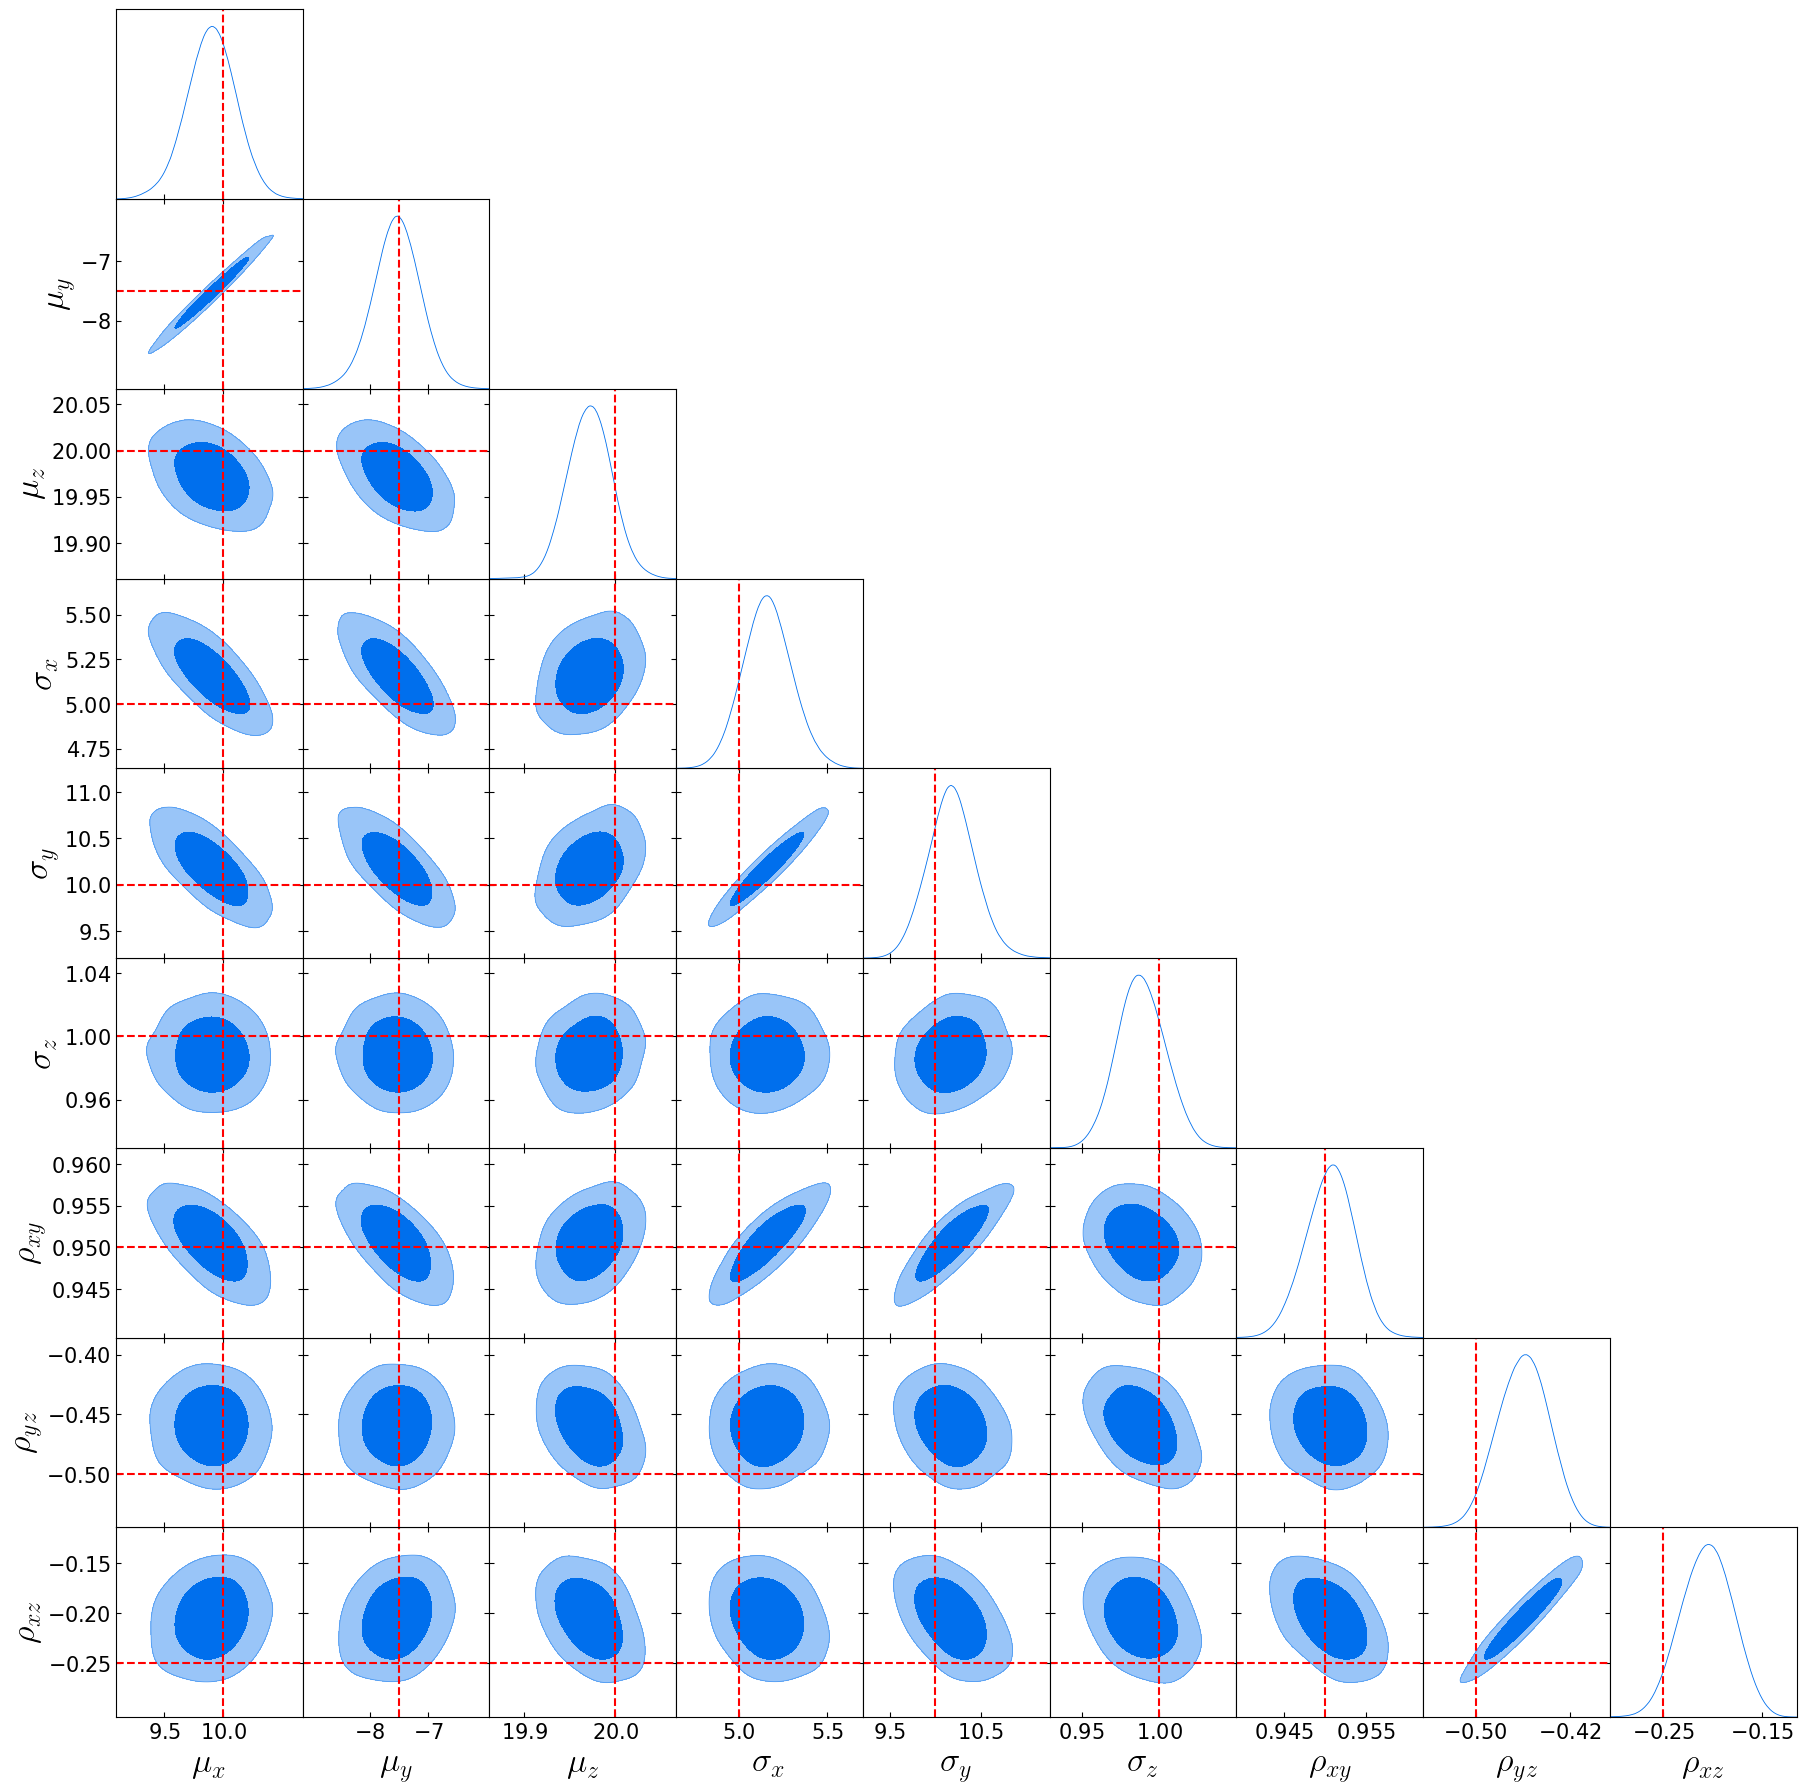

In [148]:
results = sampler.get_samples()

var_chains = results['theta']
var_x_chains = var_chains[:, 0]
var_y_chains = var_chains[:, 1]
var_z_chains = var_chains[:, 2]

corr_mat_chains = results['corr_mat']
rho_xy_chains = corr_mat_chains[:, :, 0, 1].ravel()
rho_yz_chains = corr_mat_chains[:, :, 1, 2].ravel()
rho_xz_chains = corr_mat_chains[:, :, 0, 2].ravel()

mu_x_chains = results['mu_x']
mu_y_chains = results['mu_y']
mu_z_chains = results['mu_z']

chains_dict = {
    'mu_x': mu_x_chains,
    'mu_y': mu_y_chains,
    'mu_z': mu_z_chains,
    'sigma_x': np.sqrt(var_x_chains),
    'sigma_y': np.sqrt(var_y_chains),
    'sigma_z': np.sqrt(var_z_chains),
    'rho_xy': rho_xy_chains,
    'rho_yz': rho_yz_chains,
    'rho_xz': rho_xz_chains,
}
results_chain = np.array([mu_x_chains, mu_y_chains, mu_z_chains, np.sqrt(var_x_chains), np.sqrt(var_y_chains), np.sqrt(var_z_chains), rho_xy_chains, rho_yz_chains, rho_xz_chains])

param_names = [r'$\mu_x$', r'$\mu_y$', r'$\mu_z$', r'$\sigma_x$', r'$\sigma_y$', r'$\sigma_z$', r'$\rho_{xy}$', r'$\rho_{yz}$', r'$\rho_{xz}$']
getdist_plot(results_chain, param_names, true_params, true_params)

# Truncated 3D Gaussian + errors + hard cut on 1 dimension

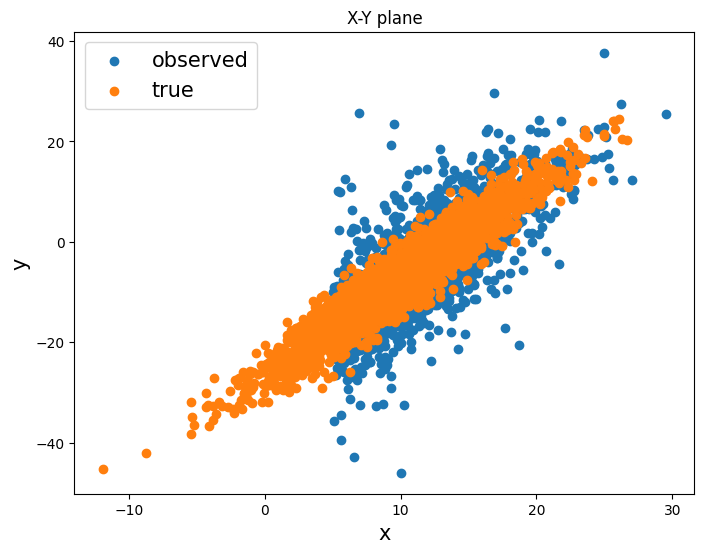

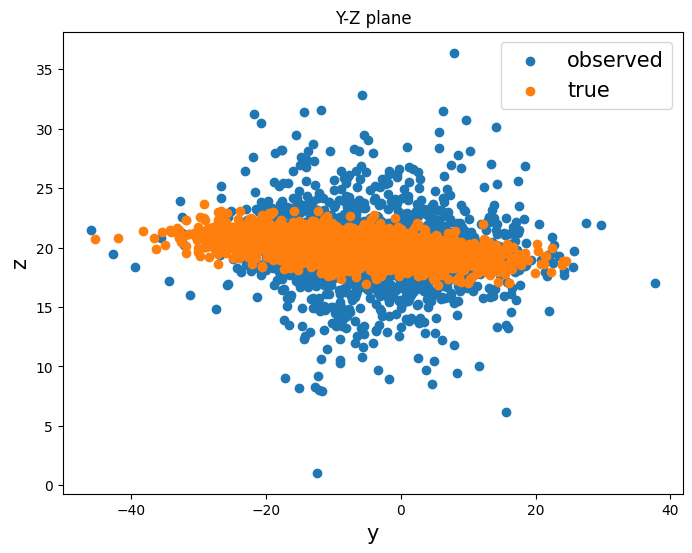

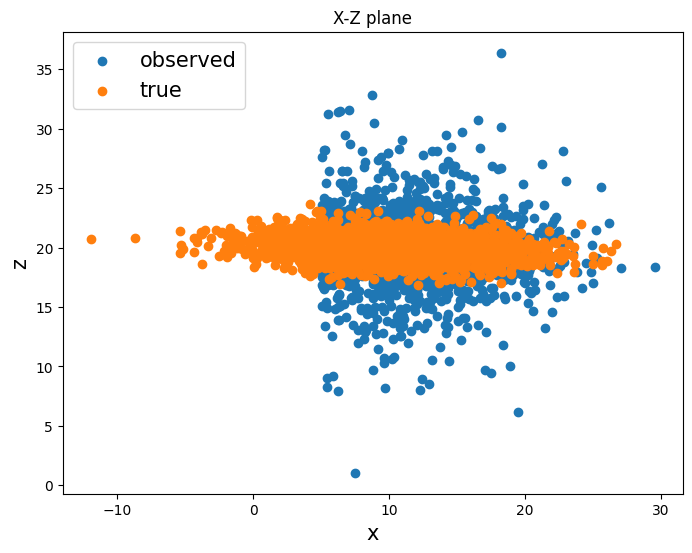

In [179]:
np.random.seed(42)

# Generate true data
N_data = 2500
mean_x = 10.0
mean_y = -7.5
mean_z = 20.0
sigma_x = 5.0
sigma_y = 10.0
sigma_z = 1.0
rho_xy = 0.95
rho_yz = -0.5
rho_xz = -0.25
true_params = [mean_x, mean_y, mean_z, sigma_x, sigma_y, sigma_z, rho_xy, rho_yz, rho_xz]

mean_vec = np.array([mean_x, mean_y, mean_z])
cov_xy = rho_xy * sigma_x * sigma_y
cov_yz = rho_yz * sigma_y * sigma_z
cov_xz = rho_xz * sigma_x * sigma_z
cov_matrix = np.array([
    [sigma_x**2, cov_xy, cov_xz],
    [cov_xy, sigma_y**2, cov_yz],
    [cov_xz, cov_yz, sigma_z**2],
])

data_true = np.random.multivariate_normal(mean=mean_vec, cov=cov_matrix, size=N_data)
x_true, y_true, z_true = data_true.T

# Convolve with measurement uncertainties
e_x_scale = 1.0
e_y_scale = 5.0
e_z_scale = 2.5
data_err = dist.HalfNormal(jnp.array([e_x_scale, e_y_scale, e_z_scale])).sample(jax.random.PRNGKey(0), sample_shape=(N_data,))
e_x, e_y, e_z = data_err.T

data_obs = data_true + np.random.normal(size=data_true.shape) * data_err

# Truncate the data
x_min = 5.0
mask = data_obs.T[0] >= x_min
data_obs = data_obs[mask]
data_err = data_err[mask]
x_obs, y_obs, z_obs = data_obs.T

plt.figure(figsize=(8, 6))
plt.title('X-Y plane')
plt.scatter(x_obs, y_obs, label='observed')
plt.scatter(x_true, y_true, label='true')
plt.xlabel('x', fontsize=15)
plt.ylabel('y', fontsize=15)
plt.legend(fontsize=15)

plt.figure(figsize=(8, 6))
plt.title('Y-Z plane')
plt.scatter(y_obs, z_obs, label='observed')
plt.scatter(y_true, z_true, label='true')
plt.xlabel('y', fontsize=15)
plt.ylabel('z', fontsize=15)
plt.legend(fontsize=15)

plt.figure(figsize=(8, 6))
plt.title('X-Z plane')
plt.scatter(x_obs, z_obs, label='observed')
plt.scatter(x_true, z_true, label='true')
plt.xlabel('x', fontsize=15)
plt.ylabel('z', fontsize=15)
plt.legend(fontsize=15)


In [201]:
def numpyro_model_truncated_3D(data, data_err, x_cut):

    # Dimension and number of data
    d = data.shape[1]
    N = data.shape[0]

    # Vector of variances for each observation
    theta = numpyro.sample('theta', dist.HalfCauchy(jnp.ones(d)))

    # Correlation matrix sampled from LKJ distribution
    concentration = jnp.ones(1) # Uniform prior
    corr_mat = numpyro.sample('corr_mat', dist.LKJ(d, concentration))

    # Construct intrinsic covariance matrix
    sigma = jnp.sqrt(theta)
    int_cov_mat = jnp.matmul(jnp.matmul(jnp.diag(sigma), corr_mat), jnp.diag(sigma))

    # Construct the error matrix for each data point
    err_matrix = jnp.square(jnp.einsum('ni,ij->nij', data_err, jnp.eye(3)))

    # Convolve the intrinsic covariance matrix with the error matrix
    cov_mat = int_cov_mat + err_matrix

    # Vector of expectation values (means)
    mu_x = numpyro.sample('mu_x', dist.Uniform(-50., 50.))
    mu_y = numpyro.sample('mu_y', dist.Uniform(-50., 50.))
    mu_z = numpyro.sample('mu_z', dist.Uniform(-50., 50.))
    mu = jnp.array([mu_x, mu_y, mu_z])

    # Calculate the f_n correction
    sigma_x = jnp.sqrt(cov_mat[:, 0, 0])
    z_val = (x_cut - mu_x) / sigma_x
    log_fn = log_ndtr(-z_val)

    # --- full log likelihood ---
    with numpyro.plate("data", N):
        loglike_full = dist.MultivariateNormal(mu, cov_mat).log_prob(data)
        numpyro.factor("trunc_ll", loglike_full - log_fn)


sampler = numpyro.infer.MCMC(
    numpyro.infer.NUTS(numpyro_model_truncated_3D),
    num_chains=1,
    num_warmup=1000,
    num_samples=3000
)

sampler.run(jax.random.PRNGKey(0), data_obs, data_err, x_min)

sample: 100%|██████████| 4000/4000 [00:44<00:00, 89.62it/s, 31 steps of size 1.55e-01. acc. prob=0.92] 


Removed no burn in


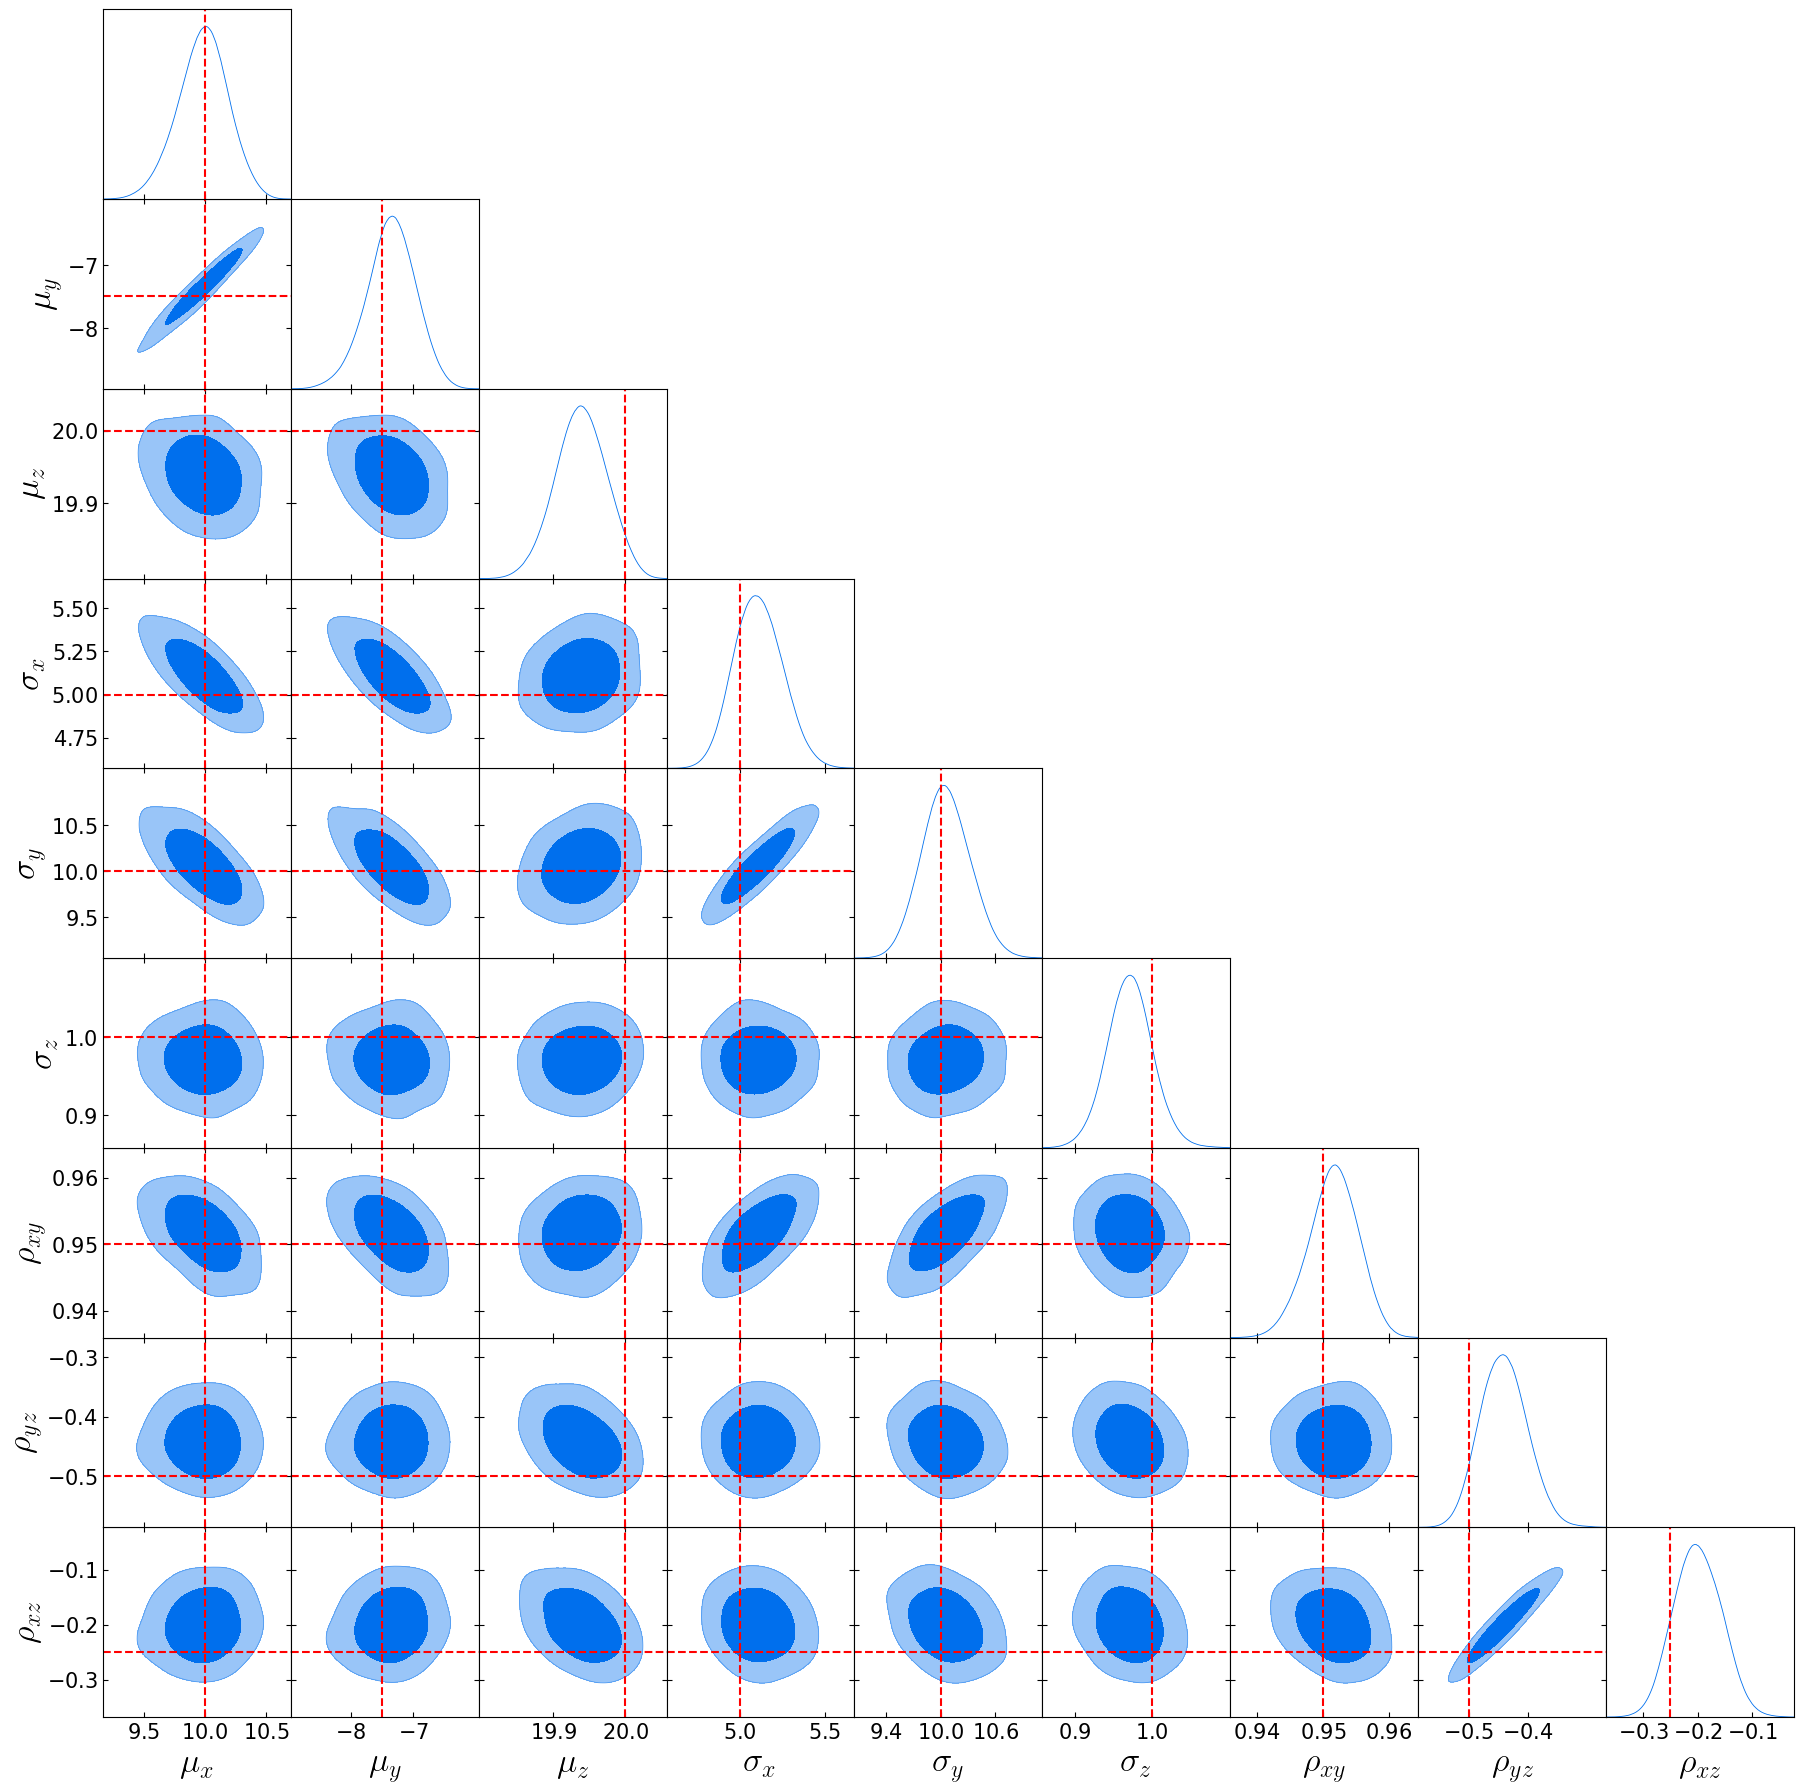

In [199]:
results = sampler.get_samples()

var_chains = results['theta']
var_x_chains = var_chains[:, 0]
var_y_chains = var_chains[:, 1]
var_z_chains = var_chains[:, 2]

corr_mat_chains = results['corr_mat']
rho_xy_chains = corr_mat_chains[:, :, 0, 1].ravel()
rho_yz_chains = corr_mat_chains[:, :, 1, 2].ravel()
rho_xz_chains = corr_mat_chains[:, :, 0, 2].ravel()

mu_x_chains = results['mu_x']
mu_y_chains = results['mu_y']
mu_z_chains = results['mu_z']

chains_dict = {
    'mu_x': mu_x_chains,
    'mu_y': mu_y_chains,
    'mu_z': mu_z_chains,
    'sigma_x': np.sqrt(var_x_chains),
    'sigma_y': np.sqrt(var_y_chains),
    'sigma_z': np.sqrt(var_z_chains),
    'rho_xy': rho_xy_chains,
    'rho_yz': rho_yz_chains,
    'rho_xz': rho_xz_chains,
}
results_chain = np.array([mu_x_chains, mu_y_chains, mu_z_chains, np.sqrt(var_x_chains), np.sqrt(var_y_chains), np.sqrt(var_z_chains), rho_xy_chains, rho_yz_chains, rho_xz_chains])

param_names = [r'$\mu_x$', r'$\mu_y$', r'$\mu_z$', r'$\sigma_x$', r'$\sigma_y$', r'$\sigma_z$', r'$\rho_{xy}$', r'$\rho_{yz}$', r'$\rho_{xz}$']
getdist_plot(results_chain, param_names, true_params, true_params)

# Truncated 3D Gaussian + no errors + hard cut on 2 dimensions

Text(0, 0.5, 'z')

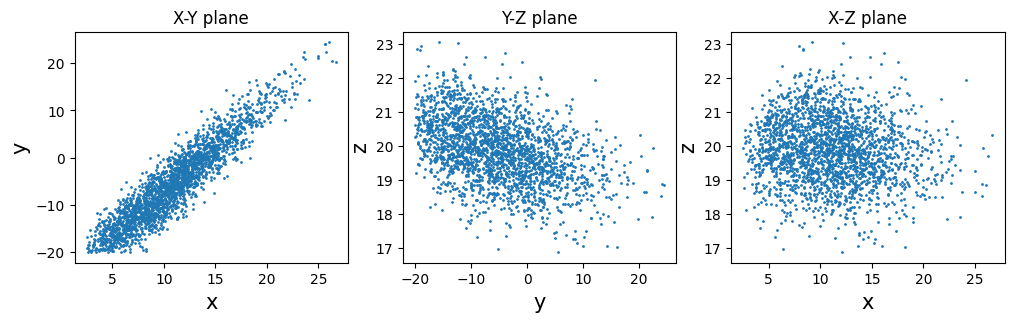

In [572]:
np.random.seed(42)

# Generate data
mean_x = 10.0
mean_y = -7.5
mean_z = 20.0
sigma_x = 5.0
sigma_y = 10.0
sigma_z = 1.0
rho_xy = 0.95
rho_yz = -0.5
rho_xz = -0.25
true_params = [mean_x, mean_y, mean_z, sigma_x, sigma_y, sigma_z, rho_xy, rho_yz, rho_xz]

mean_vec = np.array([mean_x, mean_y, mean_z])
cov_xy = rho_xy * sigma_x * sigma_y
cov_yz = rho_yz * sigma_y * sigma_z
cov_xz = rho_xz * sigma_x * sigma_z
cov_matrix = np.array([
    [sigma_x**2, cov_xy, cov_xz],
    [cov_xy, sigma_y**2, cov_yz],
    [cov_xz, cov_yz, sigma_z**2],
])

data_true = np.random.multivariate_normal(mean=mean_vec, cov=cov_matrix, size=2500)
x_true, y_true, z_true = data_true.T

# Truncate the data
x_min = 2.5
y_min = -20.0
mask = (x_true >= x_min) & (y_true >= y_min)
x_obs = x_true[mask]
y_obs = y_true[mask]
z_obs = z_true[mask]
data_obs = np.vstack([x_obs, y_obs, z_obs]).T

fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(12, 3))
ax1.scatter(x_obs, y_obs, s=1)
ax1.set_title('X-Y plane')
ax1.set_xlabel('x', fontsize=15)
ax1.set_ylabel('y', fontsize=15)

ax2.set_title('Y-Z plane')
ax2.scatter(y_obs, z_obs, s=1)
ax2.set_xlabel('y', fontsize=15)
ax2.set_ylabel('z', fontsize=15)

ax3.set_title('X-Z plane')
ax3.scatter(x_obs, z_obs, s=1)
ax3.set_xlabel('x', fontsize=15)
ax3.set_ylabel('z', fontsize=15)

In [629]:
# def bivnorm_cdf(a, b, rho):
#     """Function to calculate the integral of a standard bivariate Gaussian with correlation rho.

#     Args:
#         a (_type_): upper limit on the first axis
#         b (_type_): upper limit on the second axis
#         rho (_type_): correlation between fist and second axis
#     """
#     def integrand(x, b, rho):
#         z_val = (b - rho * x) / jnp.sqrt(1 - rho**2)
#         return norm.pdf(x) * jnp.exp(log_ndtr(z_val))

#     return trapezoid(integrand, )

import jax.numpy as jnp
from jax.scipy.stats import norm
from numpy.polynomial.hermite import hermgauss

# Precompute nodes once
n = 100
x, w = hermgauss(n)

@jax.jit
def bivnorm_cdf(a, b, rho):
    x_scaled = jnp.sqrt(2) * x
    weights = w / jnp.sqrt(jnp.pi)

    inner = norm.cdf((b - rho * x_scaled) / jnp.sqrt(1 - rho**2))
    mask = x_scaled <= a

    return jnp.sum(weights * inner * mask)

@jax.jit
def log_fn_3D_gauss(x_cut, x_mean, alpha, beta, L_11):
    """Function to calculate the integral of a 3D Gaussian, truncated on two axes.
    Derived by MB Dogruel (2022) PhD thesis.

    Args:
        x_cut (float): cut on u (first observable)
        x_mean (_type_): mean of u
        alpha (_type_): _description_
        beta (_type_): _description_
        L_11 (_type_): _description_
    """

    # First term: x_cut
    z1 = (x_cut - x_mean) / L_11
    first_term = - jnp.exp(log_ndtr(z1))

    # Second term: s_cut
    z2 = alpha / jnp.sqrt(1 + beta**2)
    second_term = - jnp.exp(log_ndtr(z2))

    # Third term: bivariate normal CDF
    third_term = bivnorm_cdf(z2, z1, -beta / jnp.sqrt(1 + beta**2))

    x = (1 + first_term + second_term + third_term)

    return jnp.where(x > 0, jnp.log(x), -jnp.inf)


# # Sanity check: integral of a full 3D Gaussian (no cut, zero correlation, zero mean) -> Cholesky matrix is L_11 = L_22 = 1 and L_21 = 0.
# x_cut = -9990.
# x_mean = 0.
# y_cut = -9990.
# y_mean = 0.
# alpha = (y_cut - y_mean) / 1
# beta = 0.
# jnp.exp(log_fn_3D_gauss(x_cut, x_mean, alpha, beta, 1.0))

bivnorm_cdf(np.inf, np.inf, 0)

Array(0.99999994, dtype=float32)

In [ ]:
from matplotlib import pyplot as plt

def BvN_leggauss( xlim, ylim,
                  mean=np.zeros(2),
                  rho=0.,
                  xmax=10, ymax=10 # x/ymax must be integers
                  ):
   
    xpix, ypix = np.indices(( xmax, ymax ))
   
    xx = xpix[ :, :, None, None ] + LEGGAUSSX[None, None, :, None]
    yy = ypix[ :, :, None, None ] + LEGGAUSSX[None, None, None, :]
    ww = np.outer( LEGGAUSSW, LEGGAUSSW )[ None, None, :, : ]

    xmean, ymean = mean
    xterm = ( xx - (xmean - xlim) )
    yterm = ( yy - (ymean - ylim) )
   
    ff = np.exp( -0.5 * (xterm**2. + yterm**2. - 2.*rho*xterm*yterm
                        ) / (1.- rho**2.)
                ) # remember to normalise later on

    # sum over subpixels to get pixels
    f = np.sum( ww * ff, axis=(-2,-1) )
   
    # sum over pixels to get integral    
    result = np.sum( f ) / ( 2.*np.pi*np.sqrt(1 - rho**2.))
    # remembering to normalise
   
    plt.scatter( xx+0.*yy, yy+0.*xx, 1, ff )
    plt.colorbar()
   
    return result
   

result = BvN_leggauss(0., 0., rho=0.99, mean=np.array((2.,2.)) )
print( result )

from scipy.special import erf
print( 0.5 * ( erf( 2 / np.sqrt(2) ) + 1 ) )

In [618]:
# Use dblquad
from scipy.integrate import quad, dblquad
from scipy.stats import multivariate_normal as mvnorm

def gauss2d( y, x, mu, cov ):
    g2d = mvnorm.pdf(np.array((x,y)), mean=mu, cov=cov)
    return g2d


def dblquad_2D_gauss(x_min, y_min, mean, cov_mat):

    gauss2d_int = dblquad( gauss2d, # function f(y,x) to integrate
                    a=x_min, b=np.inf, # scalar limits on x
                    gfun = lambda x : y_min, # fn defining lower y bound
                    hfun = lambda x : np.inf, # fn defining upper y bound
                    args = (mean, cov_mat)  # covariance matrix
                    )
    
    return gauss2d_int

dblquad_2D_gauss(0., 0, mean, cov_mat)

(0.2500000000000081, 1.2096947756552357e-08)

In [617]:
from scipy.stats import multivariate_normal
import numpy as np

def scipy_integral_3D_gauss(x_min, y_min):
    mean = [0, 0]
    cov_mat = np.identity(2)

    F2 = multivariate_normal.cdf([x_min, y_min], mean=mean, cov=cov_mat)

    Fx = norm.cdf(x_min, loc=mean[0], scale=np.sqrt(cov_mat[0,0]))
    Fy = norm.cdf(y_min, loc=mean[1], scale=np.sqrt(cov_mat[1,1]))

    prob = 1 - Fx - Fy + F2

    return prob

mvnorm.cdf(0,0)

np.float64(0.5)

In [624]:
mean = np.zeros(2)
cov_mat = np.identity(2)

# Random (x_min, y_min)
x_min_test, y_min_test = np.random.uniform(low=-5, high=5, size=(2))
print(x_min_test, y_min_test)

%timeit my_integral = jnp.exp(log_fn_3D_gauss(x_min_test, 0., y_min_test, 0., 1.0))
%timeit scipy_integral = scipy_integral_3D_gauss(x_min_test, y_min_test)
%timeit dblquad_integral = dblquad_2D_gauss(x_min_test, y_min_test, mean, cov_mat)[0]

print("My integral: ", my_integral)
print("Scipy integral: ", scipy_integral)
print("Dblquad integral: ", dblquad_integral)
print("Difference = ", my_integral - scipy_integral)
print("Difference (mine vs dblquad) = ", my_integral - dblquad_integral)

-4.384942635413615 -4.486656286763225
19 μs ± 1.89 μs per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
605 μs ± 20.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.4 s ± 7.04 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
My integral:  0.8360387
Scipy integral:  0.83604133
Dblquad integral:  0.8360413888500944
Difference =  -2.6226044e-06
Difference (mine vs dblquad) =  -2.682209e-06


In [638]:
x = np.array([1, 2, 3])

x[:, None]

array([[1],
       [2],
       [3]])

In [573]:
def numpyro_model_truncated_3D(data, x_cut, y_cut):

    # Dimension and number of data
    d = data.shape[1]
    N = data.shape[0]

    # Vector of variances for each observation
    theta = numpyro.sample('theta', dist.HalfCauchy(jnp.ones(d)))

    # Correlation matrix sampled from LKJ distribution
    concentration = jnp.ones(1) # Uniform prior
    corr_mat = numpyro.sample('corr_mat', dist.LKJ(d, concentration))

    # Vector of expectation values (means)
    mu_x = numpyro.sample('mu_x', dist.Uniform(-50., 50.))
    mu_y = numpyro.sample('mu_y', dist.Uniform(-50., 50.))
    mu_z = numpyro.sample('mu_z', dist.Uniform(-50., 50.))
    mu = jnp.array([mu_x, mu_y, mu_z])

    # Construct covariance matrix back
    sigma = jnp.sqrt(theta)
    cov_mat = jnp.matmul(jnp.matmul(jnp.diag(sigma), corr_mat), jnp.diag(sigma))

    # Strike out the third axis, apply Cholesky decomposition on the new matrix
    C_prime_matrix = cov_mat[:, :-1, :-1]
    L_matrix = jnp.linalg.cholesky(C_prime_matrix)
    # print(L_matrix.shape)

    # Calculate alpha and beta and correlation between x and y
    L_11 = L_matrix[:, 0, 0]
    L_21 = L_matrix[:, 1, 0]
    L_22 = L_matrix[:, 1, 1]
    alpha = (y_cut - mu_y) / L_22
    beta = - L_21 / L_22

    # Calculate the f_n correction
    log_fn = log_fn_3D_gauss(x_cut, mu_x, alpha, beta, L_11)
    numpyro.deterministic('log_fn', log_fn)

    # --- full log likelihood ---
    with numpyro.plate("data", N):
        loglike_full = dist.MultivariateNormal(mu, cov_mat).log_prob(data)
        # numpyro.deterministic('loglike_full', loglike_full)
        numpyro.factor("trunc_ll", loglike_full - log_fn)


sampler = numpyro.infer.MCMC(
    numpyro.infer.NUTS(numpyro_model_truncated_3D),
    num_chains=1,
    num_warmup=1000,
    num_samples=2000
)

sampler.run(jax.random.PRNGKey(0), data_obs, x_min, y_min)

sample: 100%|██████████| 3000/3000 [05:58<00:00,  8.38it/s, 1023 steps of size 4.77e-05. acc. prob=0.96]


Removed no burn in


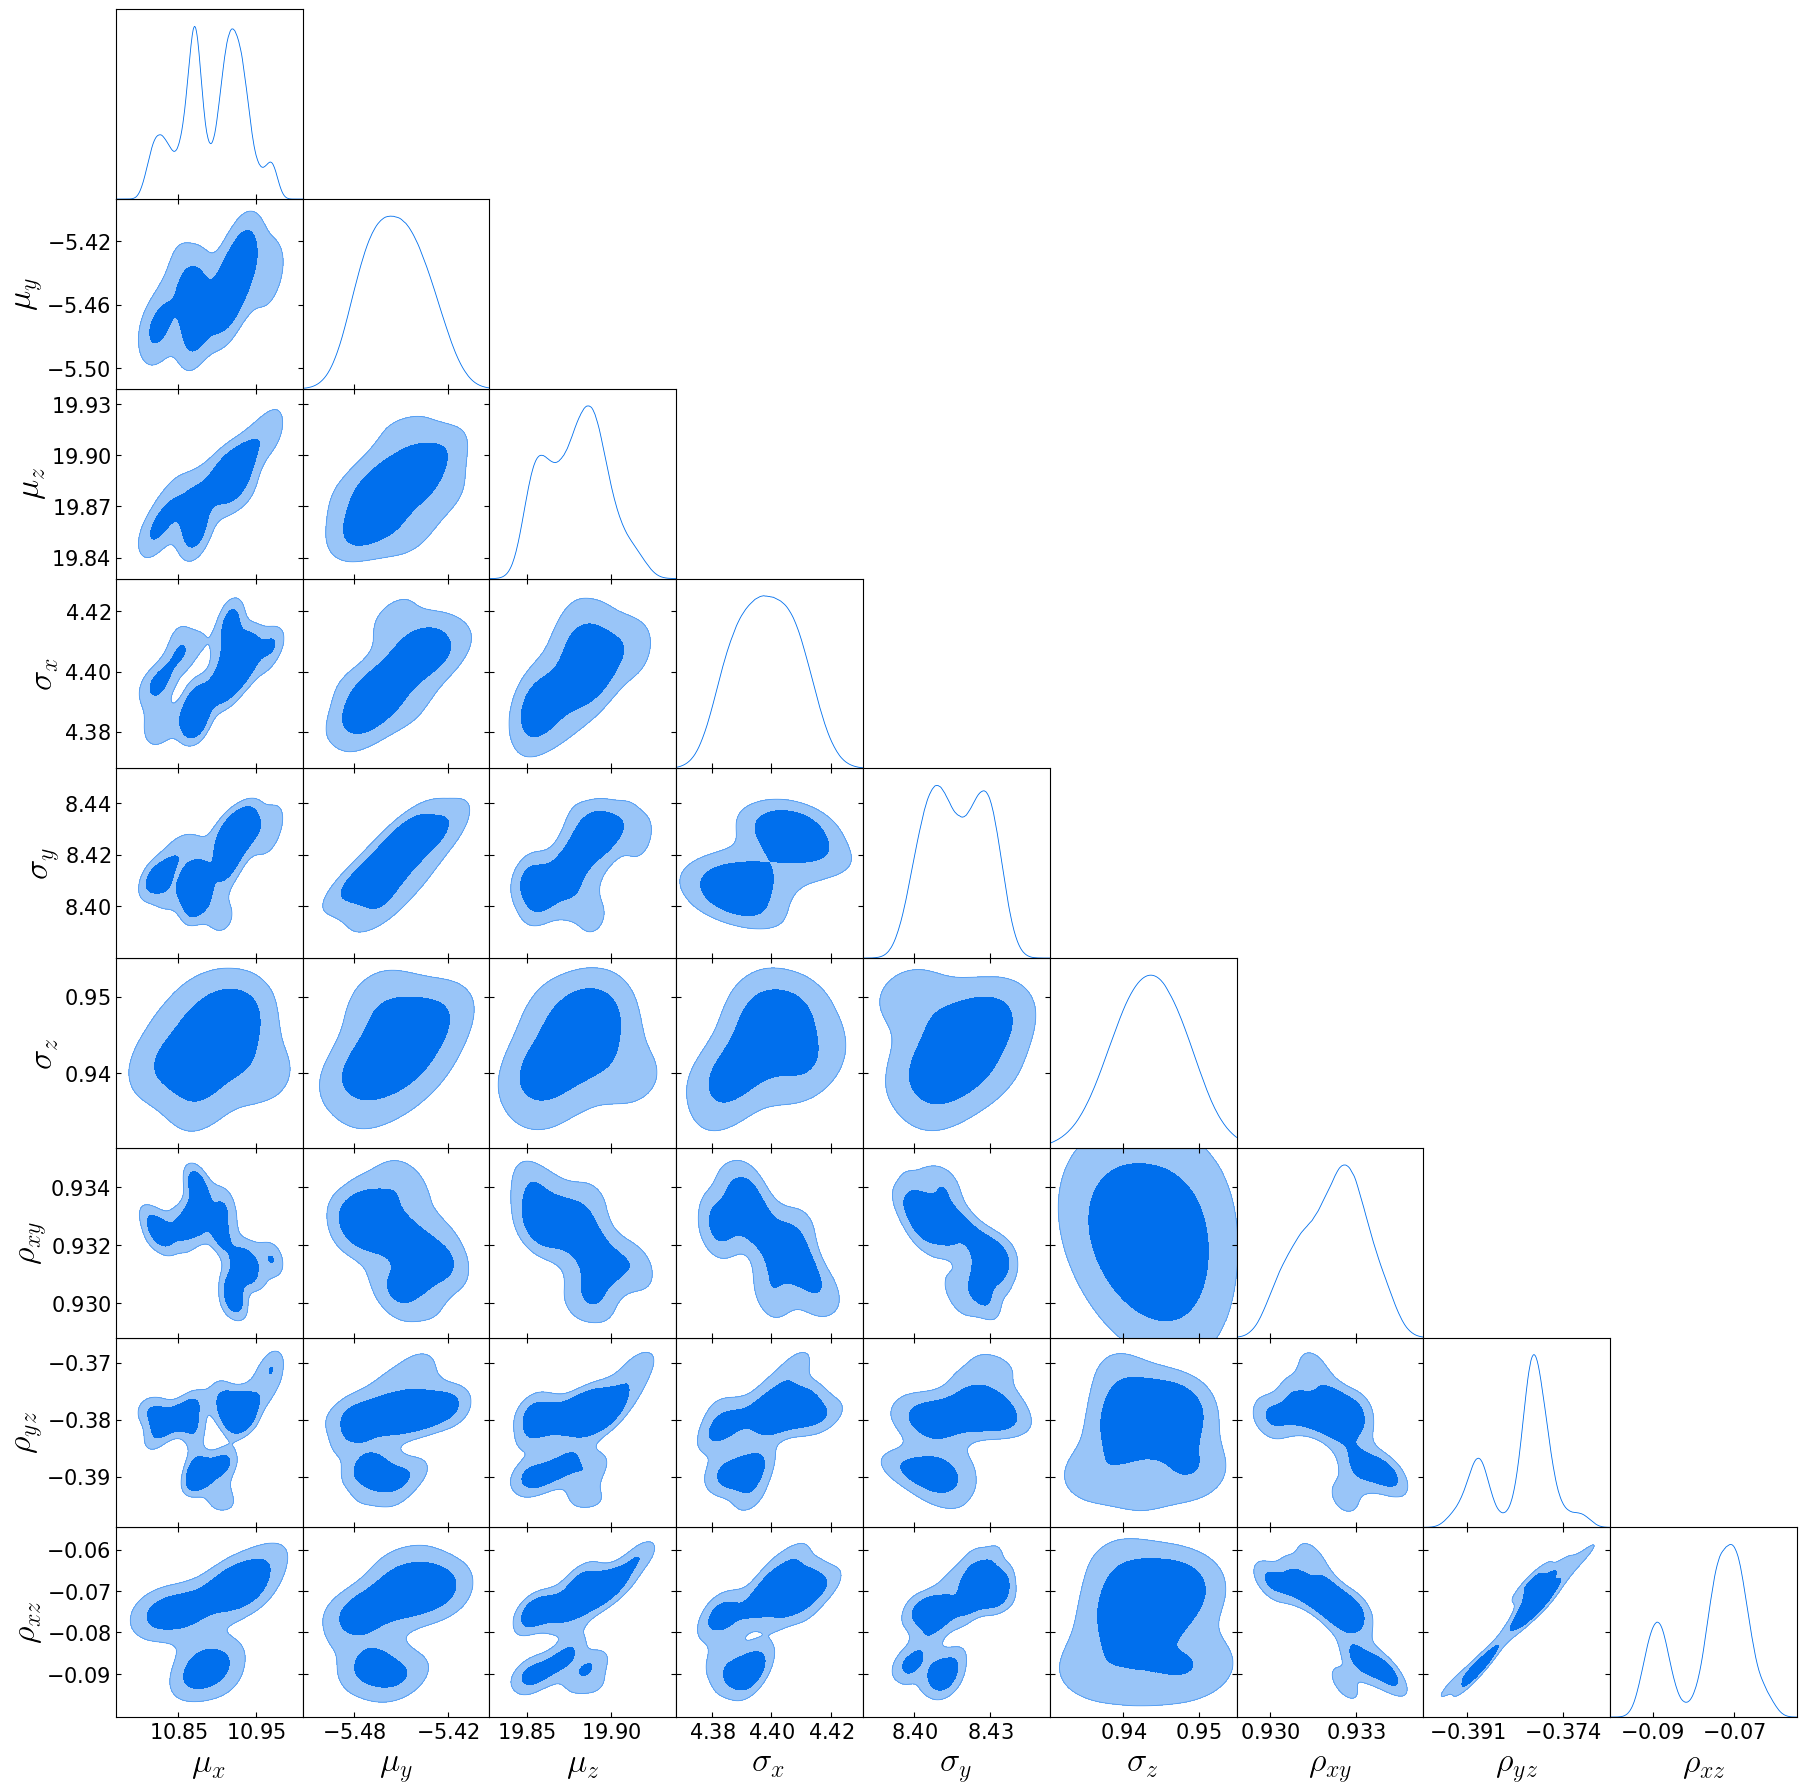

In [574]:
results = sampler.get_samples()

var_chains = results['theta']
var_x_chains = var_chains[:, 0]
var_y_chains = var_chains[:, 1]
var_z_chains = var_chains[:, 2]

corr_mat_chains = results['corr_mat']
rho_xy_chains = corr_mat_chains[:, :, 0, 1].ravel()
rho_yz_chains = corr_mat_chains[:, :, 1, 2].ravel()
rho_xz_chains = corr_mat_chains[:, :, 0, 2].ravel()

mu_x_chains = results['mu_x']
mu_y_chains = results['mu_y']
mu_z_chains = results['mu_z']

chains_dict = {
    'mu_x': mu_x_chains,
    'mu_y': mu_y_chains,
    'mu_z': mu_z_chains,
    'sigma_x': np.sqrt(var_x_chains),
    'sigma_y': np.sqrt(var_y_chains),
    'sigma_z': np.sqrt(var_z_chains),
    'rho_xy': rho_xy_chains,
    'rho_yz': rho_yz_chains,
    'rho_xz': rho_xz_chains,
}
results_chain = np.array([mu_x_chains, mu_y_chains, mu_z_chains, np.sqrt(var_x_chains), np.sqrt(var_y_chains), np.sqrt(var_z_chains), rho_xy_chains, rho_yz_chains, rho_xz_chains])

param_names = [r'$\mu_x$', r'$\mu_y$', r'$\mu_z$', r'$\sigma_x$', r'$\sigma_y$', r'$\sigma_z$', r'$\rho_{xy}$', r'$\rho_{yz}$', r'$\rho_{xz}$']
getdist_plot(results_chain, param_names, true_params, true_params)

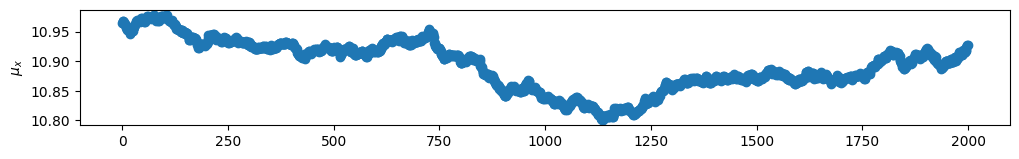

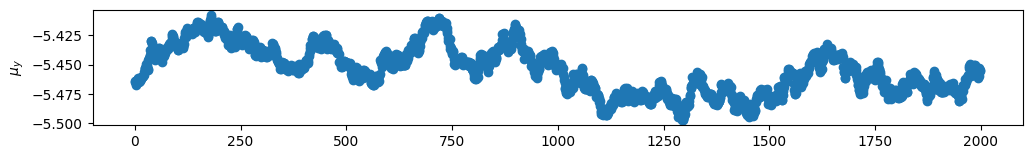

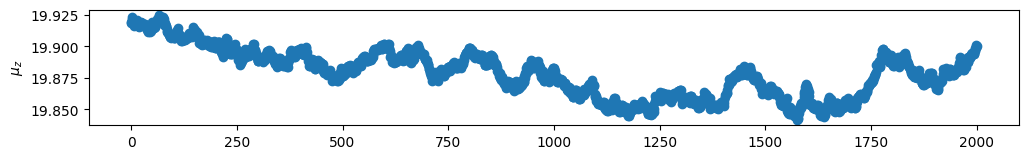

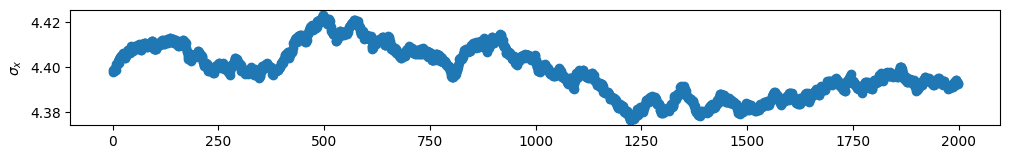

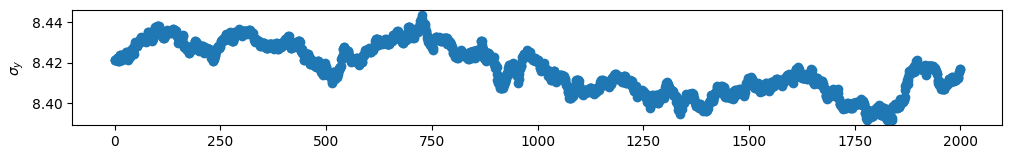

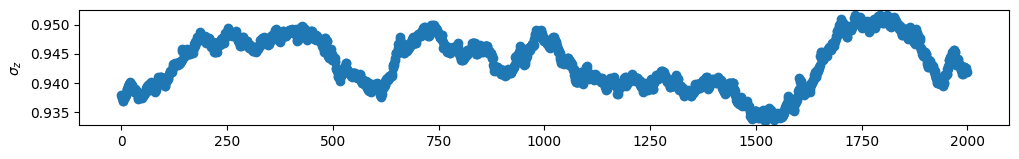

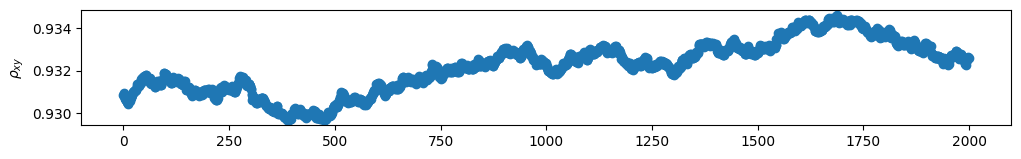

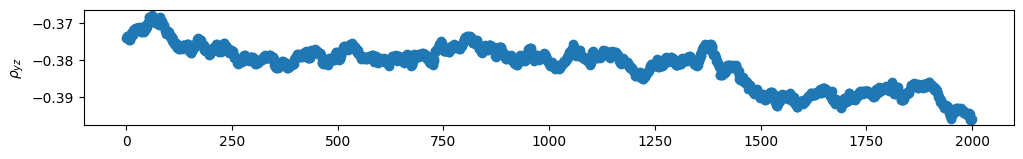

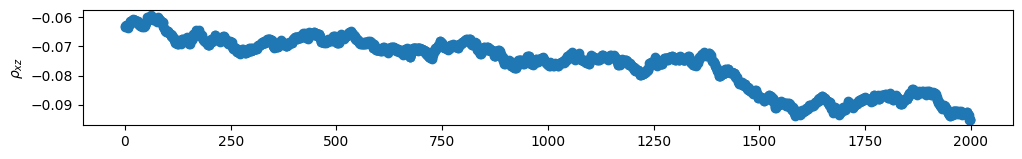

In [575]:
param_names = [r'$\mu_x$', r'$\mu_y$', r'$\mu_z$', r'$\sigma_x$', r'$\sigma_y$', r'$\sigma_z$', r'$\rho_{xy}$', r'$\rho_{yz}$', r'$\rho_{xz}$']
for i in range(9):
    x_ = results_chain[i]

    plt.figure(figsize=(12, 1.5))
    plt.scatter(list(range(len(x_))), x_)

    plt.ylabel(param_names[i])
    # plt.axhline(true_params[i])

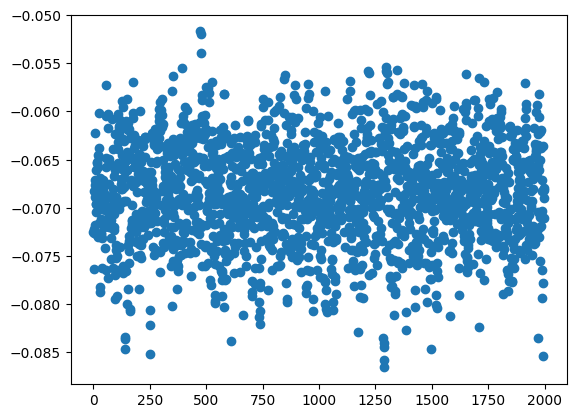

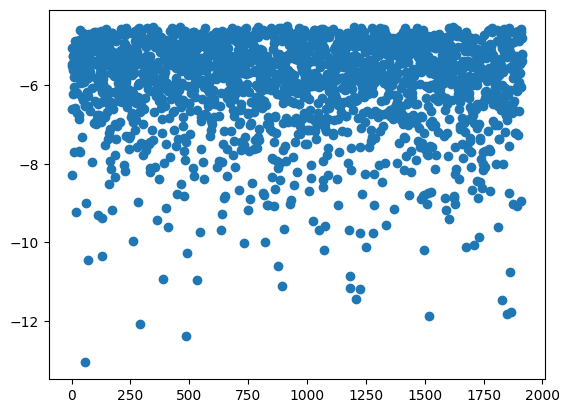

In [515]:
results = sampler.get_samples()

x_ = results['log_fn'].ravel()
plt.scatter(list(range(len(x_))), x_)

plt.figure()
x_ = results['loglike_full'][0]
plt.scatter(list(range(len(x_))), x_)

In [514]:
results['loglike_full'][0]

Array([-5.448832, -5.497419, -8.279511, ..., -5.22114 , -4.794884,
       -5.190109], dtype=float32)